In [22]:
!pip install ucimlrepo

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [24]:
# Load Spambase dataset from UCI Machine Learning Repository
spambase = fetch_ucirepo(id=94)

# Features
X = spambase.data.features.copy()

# Target
y = spambase.data.targets.copy()

print("Dataset loaded successfully.")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully.
Feature shape: (4601, 57)
Target shape: (4601, 1)


In [25]:
print("First 5 rows of features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nDataset information:")
X.info()

First 5 rows of features:


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191



Target:


,Class
0,1
1,1
2,1
3,1
4,1



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_r

In [26]:
y = y.iloc[:, 0]

print("Target values:")
print(y.value_counts())

print("\nTarget distribution (%):")
print(y.value_counts(normalize=True) * 100)

Target values:
Class
0    2788
1    1813
Name: count, dtype: int64

Target distribution (%):
Class
0    60.595523
1    39.404477
Name: proportion, dtype: float64


In [27]:
print("Missing values in features:", X.isnull().sum().sum())
print("Missing values in target:", y.isnull().sum())

Missing values in features: 0
Missing values in target: 0


In [28]:
print("=" * 50)
print("SPAMBASE DATASET SUMMARY")
print("=" * 50)

print("Number of Instances :", X.shape[0])
print("Number of Features  :", X.shape[1])
print("Number of Classes   :", y.nunique())
print("Classes             :", sorted(y.unique()))
print("Missing Values      :", X.isnull().sum().sum())

SPAMBASE DATASET SUMMARY
Number of Instances : 4601
Number of Features  : 57
Number of Classes   : 2
Classes             : [0, 1]
Missing Values      : 0


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

Training samples: 3680
Testing samples : 921

Training feature shape: (3680, 57)
Testing feature shape : (921, 57)


In [30]:
test_data = X_test.copy()
test_data["spam"] = y_test.values

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully.")
print("Shape:", test_data.shape)

display(test_data.head())

test_data.csv created successfully.
Shape: (921, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
1472,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.144,0.000,0.0,3.907,0.000,0.000,13.928,70,195,1
258,0.00,0.0,0.33,0.0,0.99,0.99,0.33,0.33,0.0,0.00,...,0.000,0.108,0.0,0.000,0.162,0.054,2.195,50,202,1
3564,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.000,0.000,0.0,0.000,0.000,0.000,1.214,4,17,0
65,0.66,0.0,0.66,0.0,0.00,0.00,0.00,0.00,0.0,0.66,...,0.000,0.000,0.0,2.205,0.000,0.000,3.184,34,121,1
4303,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.0,2.77,...,0.000,0.000,0.0,0.438,0.000,0.000,1.214,3,17,0


In [41]:
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

print("Models created successfully.")

for name in models:
    print("-", name)

Models created successfully.
- Logistic Regression
- Decision Tree
- kNN
- Naive Bayes
- Random Forest


In [43]:
def evaluate_model(model, X_test, y_test):
    
    # Predicted class
    y_pred = model.predict(X_test)

    # Predicted probability for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    }

In [45]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train model
    model.fit(X_train, y_train)

    # Store trained model
    trained_models[name] = model

    # Evaluate model
    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    # Add model name
    metrics["ML Model Name"] = name

    results.append(metrics)

    print(f"{name} completed.\n")

print("All models trained successfully.")

Training Logistic Regression...
Logistic Regression completed.

Training Decision Tree...
Decision Tree completed.

Training kNN...
kNN completed.

Training Naive Bayes...
Naive Bayes completed.

Training Random Forest...
Random Forest completed.

All models trained successfully.


In [47]:
results_df = pd.DataFrame(results)

# Put model name as first column
results_df = results_df[
    [
        "ML Model Name",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC"
    ]
]

# Round values for readability
results_df = results_df.round(4)

print("MODEL PERFORMANCE COMPARISON")
display(results_df)

MODEL PERFORMANCE COMPARISON


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9294,0.9702,0.9209,0.8981,0.9093,0.8518
1,Decision Tree,0.9110,0.9078,0.8828,0.8926,0.8877,0.8140
2,kNN,0.9077,0.9506,0.8861,0.8788,0.8824,0.8065
3,Naive Bayes,0.8339,0.9449,0.7178,0.9532,0.8189,0.6941
4,Random Forest,0.9457,0.9833,0.9510,0.9091,0.9296,0.8860


In [49]:
best_model_row = results_df.loc[results_df["F1"].idxmax()]

print("BEST MODEL BASED ON F1 SCORE")
print("--------------------------------")
print("Model     :", best_model_row["ML Model Name"])
print("Accuracy  :", best_model_row["Accuracy"])
print("AUC       :", best_model_row["AUC"])
print("Precision :", best_model_row["Precision"])
print("Recall    :", best_model_row["Recall"])
print("F1 Score  :", best_model_row["F1"])
print("MCC       :", best_model_row["MCC"])

BEST MODEL BASED ON F1 SCORE
--------------------------------
Model     : Random Forest
Accuracy  : 0.9457
AUC       : 0.9833
Precision : 0.951
Recall    : 0.9091
F1 Score  : 0.9296
MCC       : 0.886


In [51]:
for name, model in trained_models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Non-Spam", "Spam"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    Non-Spam       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921

Decision Tree
              precision    recall  f1-score   support

    Non-Spam       0.93      0.92      0.93       558
        Spam       0.88      0.89      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.91      0.91       921
weighted avg       0.91      0.91      0.91       921

kNN
              precision    recall  f1-score   support

    Non-Spam       0.92      0.93      0.92       558
        Spam       0.89      0.88      0.88       363

    accuracy                           0.91       921
   macro avg       0.90      0.90      0.90       921
weighted avg       0.91      0.91   

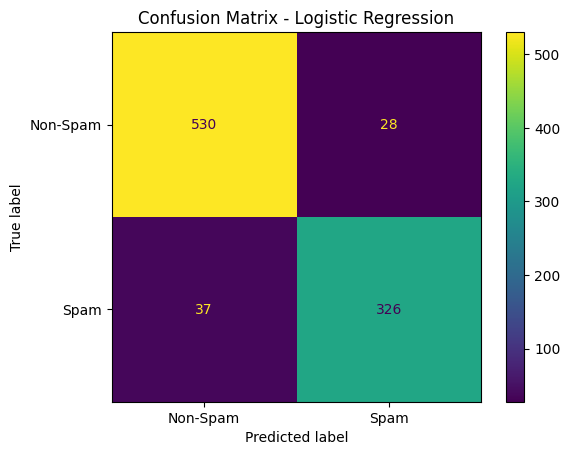

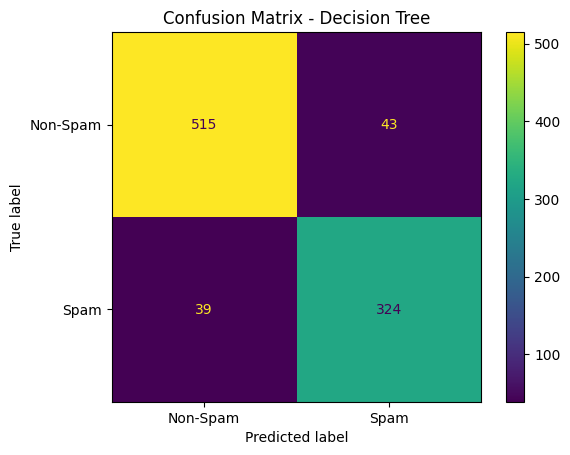

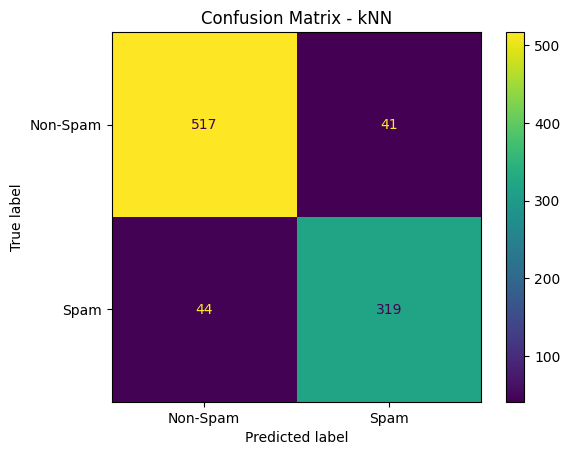

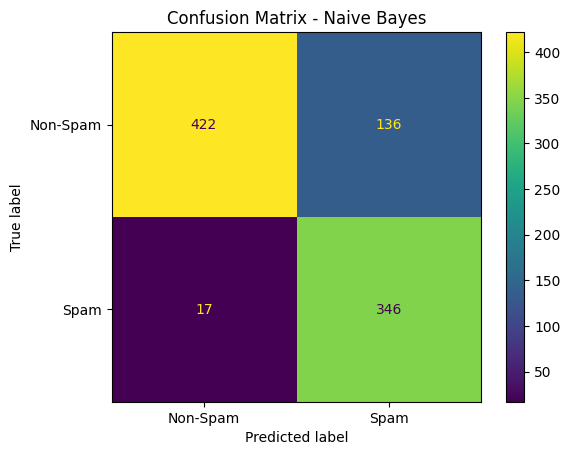

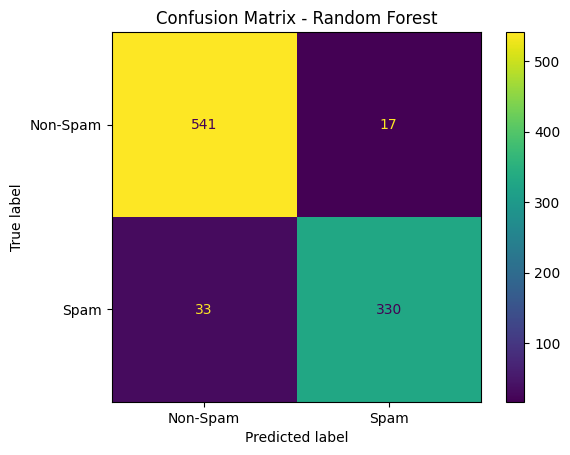

In [53]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Spam", "Spam"]
    )

    disp.plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [55]:
results_df.to_csv(
    "model_metrics.csv",
    index=False
)

print("model_metrics.csv saved successfully.")

model_metrics.csv saved successfully.


In [57]:
import os
import joblib

# Create model folder
os.makedirs("model", exist_ok=True)

joblib.dump(
    trained_models["Logistic Regression"],
    "model/logistic_regression.pkl"
)

joblib.dump(
    trained_models["Decision Tree"],
    "model/decision_tree.pkl"
)

joblib.dump(
    trained_models["kNN"],
    "model/knn.pkl"
)

joblib.dump(
    trained_models["Naive Bayes"],
    "model/naive_bayes.pkl"
)

joblib.dump(
    trained_models["Random Forest"],
    "model/random_forest.pkl"
)

print("All trained models saved successfully.")

All trained models saved successfully.


In [59]:
print("Files inside model directory:")

for file in os.listdir("model"):
    print(file)

Files inside model directory:
logistic_regression.pkl
decision_tree.pkl
knn.pkl
naive_bayes.pkl
random_forest.pkl
